# Population-scale Yq12 compositional coupling analysis

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/PersonalProjects/"
    "yq12Estimator/FinalYq12_SRKmer_Estimations.csv"
)


FATHER_SON_PATH = Path(
    "/Users/markloftus/Desktop/UCONN/PersonalProjects/"
    "yq12Estimator/fatherSon_Yq12.csv"
)

OUTPUT_DIR = Path("Yq12_population_constraint_results_v5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PERM = 100_000
MIN_HAPLOGROUP_N = 10
RANDOM_SEED = 20260826
PERM_BATCH_SIZE = 1_000

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/markloftus/Desktop/UCONN/anaconda_projects/Yq12_Estimator/Publication/Yq12_population_constraint_results_v5


## 1. Load and QC the population dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

d = df.copy()

if "Sample" not in d.columns and "Unnamed: 0" in d.columns:
    d = d.rename(columns={"Unnamed: 0": "Sample"})

required_columns = [
    "Sample",
    "Unpolished",
    "DYZ1_Counts",
    "DYZ2_Counts",
    "YHaplo",
    "YHaploBroad",
]

missing = [c for c in required_columns if c not in d.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

n_before = len(d)

d = d.dropna(
    subset=[
        "Unpolished",
        "DYZ1_Counts",
        "DYZ2_Counts",
    ]
).copy()

d = d[
    (d["Unpolished"] > 0)
    & (d["DYZ1_Counts"] > 0)
    & (d["DYZ2_Counts"] > 0)
].copy()

print(f"Rows retained after numerical QC: {len(d)} / {n_before}")

d["DYZ1_DYZ2_ratio"] = (
    d["DYZ1_Counts"] / d["DYZ2_Counts"]
)

d["log2_DYZ1"] = np.log2(d["DYZ1_Counts"])
d["log2_DYZ2"] = np.log2(d["DYZ2_Counts"])
d["log2_ratio"] = d["log2_DYZ1"] - d["log2_DYZ2"]
d["abs_log2_ratio"] = d["log2_ratio"].abs()
d["Yq12_Mb"] = d["Unpolished"] / 1e6

if "Ratio" in d.columns:
    ratio_match = np.allclose(
        d["Ratio"].to_numpy(dtype=float),
        d["DYZ1_DYZ2_ratio"].to_numpy(dtype=float),
        rtol=1e-6,
        atol=1e-10,
        equal_nan=True,
    )

    max_abs_ratio_difference = np.nanmax(
        np.abs(
            d["Ratio"].to_numpy(dtype=float)
            - d["DYZ1_DYZ2_ratio"].to_numpy(dtype=float)
        )
    )

    print("Stored Ratio == recalculated DYZ1/DYZ2:", ratio_match)
    print("Maximum absolute ratio difference:", max_abs_ratio_difference)

    if not ratio_match:
        raise ValueError(
            "Stored Ratio does not match DYZ1_Counts / DYZ2_Counts."
        )

display(
    d[
        [
            "Sample",
            "Unpolished",
            "DYZ1_Counts",
            "DYZ2_Counts",
            "DYZ1_DYZ2_ratio",
            "YHaplo",
            "YHaploBroad",
        ]
    ].head()
)

Raw shape: (1597, 8)
Columns:
['Unnamed: 0', 'Polished', 'Unpolished', 'DYZ1_Counts', 'DYZ2_Counts', 'YHaplo', 'YHaploBroad', 'Ratio']
Rows retained after numerical QC: 1597 / 1597
Stored Ratio == recalculated DYZ1/DYZ2: True
Maximum absolute ratio difference: 2.220446049250313e-16


,Sample,Unpolished,DYZ1_Counts,DYZ2_Counts,DYZ1_DYZ2_ratio,YHaplo,YHaploBroad
0,HG00477,3.367817e+07,5554.010268,5725.581489,0.970034,O2a1a1b,O2
1,HG00526,4.925648e+07,8016.958933,8530.561094,0.939793,O2a2b1a2a1,O2
2,HG01178,2.419562e+07,3942.750928,4183.446512,0.942465,R1b1a2a1a2a5,R1
3,HG02077,2.677622e+07,3917.941331,5286.397721,0.741136,O1a1a1b2a,O1
4,HG03906,2.668961e+07,4512.555283,4373.677165,1.031753,J2a1,J2


## 1B. Father-son metadata and pedigree de-related sensitivity datasets

In [3]:
fatherSonDF = pd.read_csv(FATHER_SON_PATH).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

required_fs_columns = ["Sample", "Pair", "Type"]
missing_fs = [
    c for c in required_fs_columns
    if c not in fatherSonDF.columns
]

if missing_fs:
    raise ValueError(
        f"Father-son table is missing required columns: {missing_fs}"
    )

fatherSonDF = fatherSonDF.copy()
fatherSonDF["Type"] = (
    fatherSonDF["Type"]
    .astype(str)
    .str.strip()
    .str.title()
)

valid_roles = {"Father", "Son"}
unexpected_roles = sorted(
    set(fatherSonDF["Type"].dropna().unique()) - valid_roles
)

if unexpected_roles:
    raise ValueError(
        f"Unexpected father-son role labels: {unexpected_roles}"
    )

analysis_samples = set(d["Sample"])

fs_in_analysis = fatherSonDF[
    fatherSonDF["Sample"].isin(analysis_samples)
].copy()

edges = []

for pair_id, grp in fs_in_analysis.groupby("Pair", sort=False):
    fathers = sorted(
        set(grp.loc[grp["Type"] == "Father", "Sample"])
    )
    sons = sorted(
        set(grp.loc[grp["Type"] == "Son", "Sample"])
    )

    for father in fathers:
        for son in sons:
            if father != son:
                edges.append((father, son, pair_id))

print("Father-son table rows:", len(fatherSonDF))
print("Father-son rows matched to analysis:", len(fs_in_analysis))
print("Directed parent-child edges found:", len(edges))

parent = {}

def uf_find(x):
    parent.setdefault(x, x)
    if parent[x] != x:
        parent[x] = uf_find(parent[x])
    return parent[x]

def uf_union(a, b):
    ra = uf_find(a)
    rb = uf_find(b)
    if ra != rb:
        parent[rb] = ra

for father, son, pair_id in edges:
    uf_union(father, son)

related_samples = sorted(
    set(
        [father for father, _, _ in edges]
        + [son for _, son, _ in edges]
    )
)

components = {}

for sample in related_samples:
    root = uf_find(sample)
    components.setdefault(root, []).append(sample)

components = {
    root: sorted(members)
    for root, members in components.items()
    if len(members) >= 2
}

children = {s: set() for s in related_samples}
parents = {s: set() for s in related_samples}

for father, son, pair_id in edges:
    children.setdefault(father, set()).add(son)
    parents.setdefault(son, set()).add(father)
    children.setdefault(son, set())
    parents.setdefault(father, set())

component_rows = []
founder_keep = set()
terminal_keep = set()

for component_id, members in enumerate(
    sorted(components.values(), key=lambda x: x[0]),
    start=1,
):
    member_set = set(members)

    founder_candidates = sorted([
        s for s in members
        if len(parents.get(s, set()) & member_set) == 0
    ])

    terminal_candidates = sorted([
        s for s in members
        if len(children.get(s, set()) & member_set) == 0
    ])

    founder = (
        founder_candidates[0]
        if founder_candidates
        else members[0]
    )

    terminal = (
        terminal_candidates[0]
        if terminal_candidates
        else members[-1]
    )

    founder_keep.add(founder)
    terminal_keep.add(terminal)

    component_rows.append({
        "PedigreeComponent": f"Pedigree_{component_id}",
        "N_samples": len(members),
        "Samples": ",".join(members),
        "N_founder_candidates": len(founder_candidates),
        "Founder_candidates": ",".join(founder_candidates),
        "Founder_retained": founder,
        "N_terminal_candidates": len(terminal_candidates),
        "Terminal_candidates": ",".join(terminal_candidates),
        "Terminal_retained": terminal,
    })

pedigree_components = pd.DataFrame(component_rows)

samples_in_components = set(
    s
    for members in components.values()
    for s in members
)

d_founder_retained = d[
    (~d["Sample"].isin(samples_in_components))
    | (d["Sample"].isin(founder_keep))
].copy().reset_index(drop=True)

d_terminal_retained = d[
    (~d["Sample"].isin(samples_in_components))
    | (d["Sample"].isin(terminal_keep))
].copy().reset_index(drop=True)

expected_derelated_n = (
    len(d)
    - len(samples_in_components)
    + len(components)
)

assert len(d_founder_retained) == expected_derelated_n
assert len(d_terminal_retained) == expected_derelated_n

for label, z in [
    ("Founder retained", d_founder_retained),
    ("Terminal descendant retained", d_terminal_retained),
]:
    kept = set(z["Sample"])
    remaining_edges = [
        (father, son, pair_id)
        for father, son, pair_id in edges
        if father in kept and son in kept
    ]
    if remaining_edges:
        raise ValueError(
            f"{label} still contains related father-son edges: "
            f"{remaining_edges[:10]}"
        )

father_son_qc = pd.Series({
    "analysis_N": len(d),
    "fatherSon_table_rows": len(fatherSonDF),
    "fatherSon_rows_found_in_analysis": len(fs_in_analysis),
    "unique_related_samples_in_analysis":
        len(samples_in_components),
    "parent_child_edges_in_analysis":
        len(edges),
    "connected_pedigree_components":
        len(components),
    "largest_component_N":
        (
            max(len(x) for x in components.values())
            if components else 0
        ),
    "expected_one_per_pedigree_N":
        expected_derelated_n,
    "founder_retained_N":
        len(d_founder_retained),
    "terminal_descendant_retained_N":
        len(d_terminal_retained),
})

display(father_son_qc.to_frame("value"))

print("\nPedigree components:")
display(pedigree_components.head(20))

sample_pair_role_qc = (
    fs_in_analysis
    .groupby("Sample")
    .agg(
        N_pair_IDs=("Pair", "nunique"),
        N_roles=("Type", "nunique"),
        Pair_IDs=("Pair", lambda x: ",".join(map(str, sorted(set(x))))),
        Roles=("Type", lambda x: ",".join(sorted(set(x)))),
    )
)

multi_membership = sample_pair_role_qc[
    (sample_pair_role_qc["N_pair_IDs"] > 1)
    | (sample_pair_role_qc["N_roles"] > 1)
]

print("\nSamples occurring in multiple pair IDs and/or generations:")
display(multi_membership)

Father-son table rows: 618
Father-son rows matched to analysis: 618
Directed parent-child edges found: 309


,value
analysis_N,1597
fatherSon_table_rows,618
fatherSon_rows_found_in_analysis,618
unique_related_samples_in_analysis,617
parent_child_edges_in_analysis,309
connected_pedigree_components,308
largest_component_N,3
expected_one_per_pedigree_N,1288
founder_retained_N,1288
terminal_descendant_retained_N,1288



Pedigree components:


,PedigreeComponent,N_samples,Samples,N_founder_candidates,Founder_candidates,Founder_retained,N_terminal_candidates,Terminal_candidates,Terminal_retained
0,Pedigree_1,2,"HG00418,HG00420",1,HG00418,HG00418,1,HG00420,HG00420
1,Pedigree_2,2,"HG00427,HG00429",1,HG00427,HG00427,1,HG00429,HG00429
2,Pedigree_3,2,"HG00442,HG00444",1,HG00442,HG00442,1,HG00444,HG00444
3,Pedigree_4,2,"HG00457,HG00459",1,HG00457,HG00457,1,HG00459,HG00459
4,Pedigree_5,2,"HG00463,HG00465",1,HG00463,HG00463,1,HG00465,HG00465
5,Pedigree_6,2,"HG00472,HG00474",1,HG00472,HG00472,1,HG00474,HG00474
6,Pedigree_7,2,"HG00475,HG00477",1,HG00475,HG00475,1,HG00477,HG00477
7,Pedigree_8,2,"HG00478,HG00480",1,HG00478,HG00478,1,HG00480,HG00480
8,Pedigree_9,2,"HG00500,HG00502",1,HG00500,HG00500,1,HG00502,HG00502
9,Pedigree_10,2,"HG00524,HG00526",1,HG00524,HG00524,1,HG00526,HG00526



Samples occurring in multiple pair IDs and/or generations:


,N_pair_IDs,N_roles,Pair_IDs,Roles
Sample,,,,
HG03679,2,1,"Pair_205,Pair_206",Father


## 2. Population-scale descriptive summaries

In [4]:
population_summary = pd.Series({
    "N": len(d),
    "Yq12_length_Mb_mean": d["Yq12_Mb"].mean(),
    "Yq12_length_Mb_median": d["Yq12_Mb"].median(),
    "Yq12_length_Mb_min": d["Yq12_Mb"].min(),
    "Yq12_length_Mb_max": d["Yq12_Mb"].max(),
    "DYZ1_count_mean": d["DYZ1_Counts"].mean(),
    "DYZ2_count_mean": d["DYZ2_Counts"].mean(),
    "DYZ1_DYZ2_ratio_mean": d["DYZ1_DYZ2_ratio"].mean(),
    "DYZ1_DYZ2_ratio_median": d["DYZ1_DYZ2_ratio"].median(),
    "DYZ1_DYZ2_ratio_min": d["DYZ1_DYZ2_ratio"].min(),
    "DYZ1_DYZ2_ratio_max": d["DYZ1_DYZ2_ratio"].max(),
    "SD_log2_DYZ1_DYZ2_ratio": d["log2_ratio"].std(ddof=1),
    "median_abs_log2_DYZ1_DYZ2_ratio": d["abs_log2_ratio"].median(),
    "Pearson_r_log2_DYZ1_log2_DYZ2":
        d["log2_DYZ1"].corr(d["log2_DYZ2"], method="pearson"),
    "Spearman_rho_DYZ1_DYZ2":
        d["DYZ1_Counts"].corr(d["DYZ2_Counts"], method="spearman"),
})

display(population_summary.to_frame("value"))

,value
N,1597.000000
Yq12_length_Mb_mean,26.507963
Yq12_length_Mb_median,25.479107
Yq12_length_Mb_min,0.931450
Yq12_length_Mb_max,52.107356
DYZ1_count_mean,4312.132583
DYZ2_count_mean,4594.198984
DYZ1_DYZ2_ratio_mean,0.963378
DYZ1_DYZ2_ratio_median,0.944386
DYZ1_DYZ2_ratio_min,0.529232


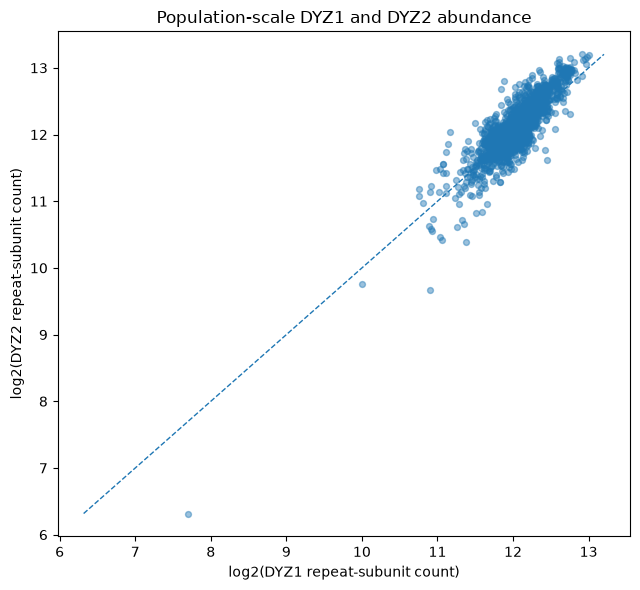

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))

x = d["log2_DYZ1"].to_numpy()
y = d["log2_DYZ2"].to_numpy()

ax.scatter(x, y, alpha=0.45, s=18)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())

ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

ax.set_xlabel("log2(DYZ1 repeat-subunit count)")
ax.set_ylabel("log2(DYZ2 repeat-subunit count)")
ax.set_title("Population-scale DYZ1 and DYZ2 abundance")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "DYZ1_DYZ2_population_scatter.pdf",
    bbox_inches="tight",
)
plt.show()

## 3. Primary test: are DYZ1 and DYZ2 paired more tightly than expected?

In [6]:
def stratified_pairing_permutation(
    data,
    group_col,
    n_perm=100_000,
    seed=20260826,
    batch_size=1_000,
):
    """
    Randomly re-pair log2(DYZ2) with log2(DYZ1) within strata.

    Primary statistic:
        SD[log2(DYZ1/DYZ2)]

    The implementation uses:
        sum((x-y)^2) = sum(x^2) + sum(y^2) - 2*sum(x*y)
    """
    z = data[
        [
            "log2_DYZ1",
            "log2_DYZ2",
            group_col,
        ]
    ].dropna().copy()

    x = z["log2_DYZ1"].to_numpy(dtype=float)
    y = z["log2_DYZ2"].to_numpy(dtype=float)

    n = len(z)
    if n < 3:
        raise ValueError("At least 3 observations are required.")

    groups = [
        idx.to_numpy(dtype=int)
        for _, idx in z.groupby(group_col, sort=False).groups.items()
    ]

    group_sizes = np.array([len(idx) for idx in groups])

    print(
        f"{group_col}: {len(groups)} strata; "
        f"N={n}; size range={group_sizes.min()}-{group_sizes.max()}"
    )

    singleton_n = int(np.sum(group_sizes == 1))
    if singleton_n:
        print(
            f"Note: {singleton_n} singleton strata cannot be permuted "
            "and therefore remain fixed (conservative)."
        )

    sum_x2 = np.sum(x * x)
    sum_y2 = np.sum(y * y)

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    mean_ratio = mean_x - mean_y

    ssx = sum_x2 - n * mean_x**2
    ssy = sum_y2 - n * mean_y**2
    denom_r = np.sqrt(ssx * ssy)

    observed_sum_xy = np.sum(x * y)

    observed_sum_sq_ratio = (
        sum_x2 + sum_y2 - 2.0 * observed_sum_xy
    )

    observed_var_ratio = (
        observed_sum_sq_ratio - n * mean_ratio**2
    ) / (n - 1)

    observed_sd_ratio = np.sqrt(max(observed_var_ratio, 0.0))

    observed_r = (
        observed_sum_xy - n * mean_x * mean_y
    ) / denom_r

    rng = np.random.default_rng(seed)

    perm_sd = np.empty(n_perm, dtype=float)
    perm_r = np.empty(n_perm, dtype=float)

    start = 0

    while start < n_perm:
        stop = min(start + batch_size, n_perm)
        b = stop - start

        cross_products = np.zeros(b, dtype=float)

        for idx in groups:
            m = len(idx)

            if m == 1:
                cross_products += x[idx[0]] * y[idx[0]]
                continue

            random_keys = rng.random((b, m))
            orders = np.argsort(random_keys, axis=1)

            y_group = y[idx]
            y_perm = y_group[orders]

            cross_products += np.sum(
                x[idx][None, :] * y_perm,
                axis=1,
            )

        sum_sq_ratio = (
            sum_x2 + sum_y2 - 2.0 * cross_products
        )

        var_ratio = (
            sum_sq_ratio - n * mean_ratio**2
        ) / (n - 1)

        perm_sd[start:stop] = np.sqrt(
            np.maximum(var_ratio, 0.0)
        )

        perm_r[start:stop] = (
            cross_products - n * mean_x * mean_y
        ) / denom_r

        start = stop

    p_lower_sd = (
        1 + np.sum(perm_sd <= observed_sd_ratio)
    ) / (n_perm + 1)

    return {
        "N": n,
        "n_strata": len(groups),
        "observed_SD_log2_ratio": observed_sd_ratio,
        "null_SD_median": np.median(perm_sd),
        "null_SD_2.5_percentile": np.quantile(perm_sd, 0.025),
        "null_SD_97.5_percentile": np.quantile(perm_sd, 0.975),
        "null_to_observed_SD_fold":
            np.median(perm_sd) / observed_sd_ratio,
        "Monte_Carlo_p_ratio_dispersion": p_lower_sd,
        "observed_Pearson_r": observed_r,
        "null_r_median": np.median(perm_r),
        "null_r_2.5_percentile": np.quantile(perm_r, 0.025),
        "null_r_97.5_percentile": np.quantile(perm_r, 0.975),
        "perm_sd": perm_sd,
        "perm_r": perm_r,
    }

In [7]:
primary_data = d.dropna(
    subset=["YHaploBroad"]
).reset_index(drop=True)

primary_pairing = stratified_pairing_permutation(
    primary_data,
    group_col="YHaploBroad",
    n_perm=N_PERM,
    seed=RANDOM_SEED,
    batch_size=PERM_BATCH_SIZE,
)

primary_summary = pd.Series({
    k: v
    for k, v in primary_pairing.items()
    if not isinstance(v, np.ndarray)
})

display(primary_summary.to_frame("value"))

YHaploBroad: 27 strata; N=1597; size range=1-459
Note: 2 singleton strata cannot be permuted and therefore remain fixed (conservative).


,value
N,1597.000000
n_strata,27.000000
observed_SD_log2_ratio,0.216806
null_SD_median,0.491278
null_SD_2.5_percentile,0.479270
null_SD_97.5_percentile,0.502312
null_to_observed_SD_fold,2.265981
Monte_Carlo_p_ratio_dispersion,0.000010
observed_Pearson_r,0.866338
null_r_median,0.200873


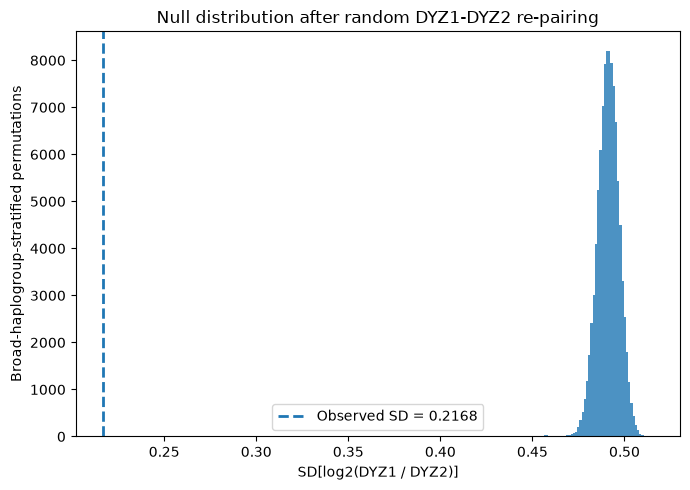

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    primary_pairing["perm_sd"],
    bins=60,
    alpha=0.8,
)

ax.axvline(
    primary_pairing["observed_SD_log2_ratio"],
    linestyle="--",
    linewidth=2,
    label=(
        "Observed SD = "
        f"{primary_pairing['observed_SD_log2_ratio']:.4f}"
    ),
)

ax.set_xlabel("SD[log2(DYZ1 / DYZ2)]")
ax.set_ylabel("Broad-haplogroup-stratified permutations")
ax.set_title("Null distribution after random DYZ1-DYZ2 re-pairing")
ax.legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "broad_haplogroup_pairing_null.pdf",
    bbox_inches="tight",
)
plt.show()

## 4. Sensitivity test: re-pair only within well-sampled detailed haplogroups

In [9]:
detailed_counts = d["YHaplo"].value_counts(dropna=True)

eligible_detailed_haplogroups = detailed_counts[
    detailed_counts >= MIN_HAPLOGROUP_N
].index

d_detailed = d[
    d["YHaplo"].isin(eligible_detailed_haplogroups)
].copy().reset_index(drop=True)

print(
    f"Detailed haplogroups with N >= {MIN_HAPLOGROUP_N}: "
    f"{len(eligible_detailed_haplogroups)}"
)
print(
    f"Samples retained for detailed-haplogroup analysis: "
    f"{len(d_detailed)}"
)

detailed_pairing = stratified_pairing_permutation(
    d_detailed,
    group_col="YHaplo",
    n_perm=N_PERM,
    seed=RANDOM_SEED + 1,
    batch_size=PERM_BATCH_SIZE,
)

detailed_pairing_summary = pd.Series({
    k: v
    for k, v in detailed_pairing.items()
    if not isinstance(v, np.ndarray)
})

display(detailed_pairing_summary.to_frame("value"))

Detailed haplogroups with N >= 10: 27
Samples retained for detailed-haplogroup analysis: 697
YHaplo: 27 strata; N=697; size range=10-76


,value
N,697.000000
n_strata,27.000000
observed_SD_log2_ratio,0.187627
null_SD_median,0.460674
null_SD_2.5_percentile,0.443075
null_SD_97.5_percentile,0.473184
null_to_observed_SD_fold,2.455266
Monte_Carlo_p_ratio_dispersion,0.000010
observed_Pearson_r,0.892358
null_r_median,0.222668


## 4B. Pedigree sensitivity: repeat the pairing tests after de-related sampling

In [10]:
def run_pairing_suite(
    data,
    label,
    min_haplogroup_n=10,
    seed_offset=0,
):
    """
    Run:
      1) broad-haplogroup stratified pairing test;
      2) detailed-haplogroup stratified pairing test among groups
         with N >= min_haplogroup_n.
    """
    broad_data = data.dropna(
        subset=["YHaploBroad"]
    ).reset_index(drop=True)

    broad = stratified_pairing_permutation(
        broad_data,
        group_col="YHaploBroad",
        n_perm=N_PERM,
        seed=RANDOM_SEED + seed_offset,
        batch_size=PERM_BATCH_SIZE,
    )

    detailed_counts_local = (
        data["YHaplo"]
        .value_counts(dropna=True)
    )

    eligible_local = detailed_counts_local[
        detailed_counts_local >= min_haplogroup_n
    ].index

    detailed_data = data[
        data["YHaplo"].isin(eligible_local)
    ].copy().reset_index(drop=True)

    detailed = stratified_pairing_permutation(
        detailed_data,
        group_col="YHaplo",
        n_perm=N_PERM,
        seed=RANDOM_SEED + seed_offset + 1,
        batch_size=PERM_BATCH_SIZE,
    )

    summary = pd.DataFrame([
        {
            "dataset": label,
            "analysis": "within YHaploBroad",
            "N": broad["N"],
            "n_strata": broad["n_strata"],
            "observed_SD_log2_ratio":
                broad["observed_SD_log2_ratio"],
            "null_SD_median":
                broad["null_SD_median"],
            "null_to_observed_SD_fold":
                broad["null_to_observed_SD_fold"],
            "Monte_Carlo_p":
                broad["Monte_Carlo_p_ratio_dispersion"],
            "observed_Pearson_r":
                broad["observed_Pearson_r"],
        },
        {
            "dataset": label,
            "analysis":
                f"within detailed YHaplo (N>={min_haplogroup_n})",
            "N": detailed["N"],
            "n_strata": detailed["n_strata"],
            "observed_SD_log2_ratio":
                detailed["observed_SD_log2_ratio"],
            "null_SD_median":
                detailed["null_SD_median"],
            "null_to_observed_SD_fold":
                detailed["null_to_observed_SD_fold"],
            "Monte_Carlo_p":
                detailed["Monte_Carlo_p_ratio_dispersion"],
            "observed_Pearson_r":
                detailed["observed_Pearson_r"],
        },
    ])

    return {
        "broad": broad,
        "detailed": detailed,
        "detailed_data": detailed_data,
        "eligible_detailed_haplogroups": eligible_local,
        "summary": summary,
    }


founder_retained_pairing = run_pairing_suite(
    d_founder_retained,
    label="Founder retained",
    min_haplogroup_n=MIN_HAPLOGROUP_N,
    seed_offset=100,
)

terminal_retained_pairing = run_pairing_suite(
    d_terminal_retained,
    label="Terminal descendant retained",
    min_haplogroup_n=MIN_HAPLOGROUP_N,
    seed_offset=200,
)

father_son_pairing_sensitivity = pd.concat(
    [
        founder_retained_pairing["summary"],
        terminal_retained_pairing["summary"],
    ],
    ignore_index=True,
)

display(father_son_pairing_sensitivity)

YHaploBroad: 27 strata; N=1288; size range=1-338
Note: 2 singleton strata cannot be permuted and therefore remain fixed (conservative).
YHaplo: 21 strata; N=501; size range=10-55
YHaploBroad: 27 strata; N=1288; size range=1-338
Note: 2 singleton strata cannot be permuted and therefore remain fixed (conservative).
YHaplo: 21 strata; N=501; size range=10-55


,dataset,analysis,N,n_strata,observed_SD_log2_ratio,null_SD_median,null_to_observed_SD_fold,Monte_Carlo_p,observed_Pearson_r
0,Founder retained,within YHaploBroad,1288,27,0.211046,0.460272,2.180909,0.00001,0.857843
1,Founder retained,within detailed YHaplo (N>=10),501,21,0.177739,0.386896,2.176757,0.00001,0.866525
2,Terminal descendant retained,within YHaploBroad,1288,27,0.217965,0.503359,2.309351,0.00001,0.873709
3,Terminal descendant retained,within detailed YHaplo (N>=10),501,21,0.192072,0.504107,2.624567,0.00001,0.903525


## 5. Describe DYZ1/DYZ2 composition within detailed Y haplogroups

In [11]:
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

haplogroup_summary = (
    d_detailed
    .groupby("YHaplo", sort=True)
    .agg(
        N=("Sample", "size"),
        Yq12_median_Mb=("Yq12_Mb", "median"),
        Yq12_min_Mb=("Yq12_Mb", "min"),
        Yq12_max_Mb=("Yq12_Mb", "max"),
        DYZ1_DYZ2_ratio_mean=("DYZ1_DYZ2_ratio", "mean"),
        DYZ1_DYZ2_ratio_median=("DYZ1_DYZ2_ratio", "median"),
        SD_log2_ratio=("log2_ratio", "std"),
        median_abs_log2_ratio=("abs_log2_ratio", "median"),
    )
)

ratio_iqr = (
    d_detailed
    .groupby("YHaplo")["DYZ1_DYZ2_ratio"]
    .apply(iqr)
    .rename("DYZ1_DYZ2_ratio_IQR")
)

haplogroup_summary = (
    haplogroup_summary
    .join(ratio_iqr)
    .sort_values("DYZ1_DYZ2_ratio_median")
)

display(haplogroup_summary)

,N,Yq12_median_Mb,Yq12_min_Mb,Yq12_max_Mb,DYZ1_DYZ2_ratio_mean,DYZ1_DYZ2_ratio_median,SD_log2_ratio,median_abs_log2_ratio,DYZ1_DYZ2_ratio_IQR
YHaplo,,,,,,,,,
O2a2a1a1a,15,30.205435,27.918485,32.421581,0.792436,0.807905,0.087647,0.307742,0.058977
J1a2b,12,34.998232,18.888922,44.482404,0.865455,0.840766,0.098876,0.250232,0.052757
O2a2b1a2a1,23,37.655159,30.979212,50.255205,0.882887,0.871541,0.161844,0.209440,0.099999
R1b1a2a1a2a1b1a1,12,23.589296,22.361610,41.847255,0.876226,0.878989,0.087519,0.186087,0.061117
R1b1a2a1a2b,22,22.952400,20.597042,28.317204,0.909491,0.881260,0.127498,0.182380,0.079195
R1a1a1b2a2a,18,27.014329,12.736630,32.380681,0.899797,0.901364,0.095141,0.149827,0.078411
R1b1a2a1a2a1a1a1a,14,24.153555,20.792297,25.397687,0.902509,0.901651,0.063256,0.149360,0.052851
R1a1a1b2a1b,23,26.171957,16.248582,31.441999,0.964287,0.906489,0.160602,0.156370,0.131771
R1b1a2a1a2a,50,23.684880,14.249415,31.104508,0.906312,0.913094,0.110902,0.153242,0.084808


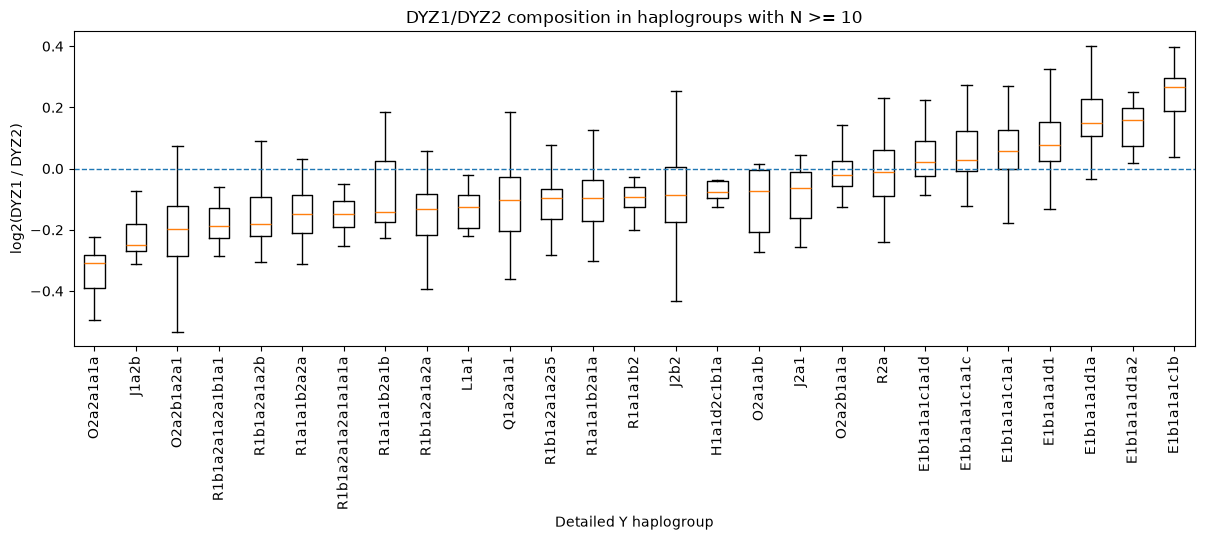

In [12]:
plot_order = haplogroup_summary.index.tolist()

box_data = [
    d_detailed.loc[
        d_detailed["YHaplo"] == hap,
        "log2_ratio"
    ].to_numpy()
    for hap in plot_order
]

fig_width = max(8, 0.45 * len(plot_order))

fig, ax = plt.subplots(figsize=(fig_width, 5.5))

ax.boxplot(
    box_data,
    tick_labels=plot_order,
    showfliers=False,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_ylabel("log2(DYZ1 / DYZ2)")
ax.set_xlabel("Detailed Y haplogroup")
ax.set_title(
    f"DYZ1/DYZ2 composition in haplogroups with N >= {MIN_HAPLOGROUP_N}"
)

plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "DYZ1_DYZ2_ratio_by_detailed_haplogroup.pdf",
    bbox_inches="tight",
)
plt.show()

## 6. Does DYZ1/DYZ2 composition differ among Y lineages?

In [13]:
groups_for_kw = [
    grp["log2_ratio"].to_numpy()
    for _, grp in d_detailed.groupby("YHaplo", sort=True)
]

k = len(groups_for_kw)
n_kw = sum(len(x) for x in groups_for_kw)

if k < 2:
    raise ValueError(
        "At least two detailed haplogroups are required for Kruskal-Wallis."
    )

kw = stats.kruskal(*groups_for_kw)

epsilon_squared = (
    (kw.statistic - k + 1)
    / (n_kw - k)
)

epsilon_squared = max(0.0, float(epsilon_squared))

lineage_structure_summary = pd.Series({
    "N": n_kw,
    "number_of_haplogroups": k,
    "minimum_haplogroup_N": MIN_HAPLOGROUP_N,
    "Kruskal_Wallis_H": kw.statistic,
    "Kruskal_Wallis_df": k - 1,
    "Kruskal_Wallis_p": kw.pvalue,
    "Kruskal_Wallis_epsilon_squared": epsilon_squared,
    "approximate_rank_variance_explained_percent":
        100 * epsilon_squared,
})

display(lineage_structure_summary.to_frame("value"))

,value
N,6.970000e+02
number_of_haplogroups,2.700000e+01
minimum_haplogroup_N,1.000000e+01
Kruskal_Wallis_H,3.826799e+02
Kruskal_Wallis_df,2.600000e+01
Kruskal_Wallis_p,4.279800e-65
Kruskal_Wallis_epsilon_squared,5.323580e-01
approximate_rank_variance_explained_percent,5.323580e+01


## 6B. Pedigree sensitivity for haplogroup composition structure

In [14]:
def lineage_structure_test(
    data,
    min_haplogroup_n=10,
    label="dataset",
):
    counts = data["YHaplo"].value_counts(dropna=True)
    eligible = counts[counts >= min_haplogroup_n].index

    z = data[
        data["YHaplo"].isin(eligible)
    ].copy()

    groups = [
        grp["log2_ratio"].to_numpy()
        for _, grp in z.groupby("YHaplo", sort=True)
    ]

    k_local = len(groups)
    n_local = sum(len(g) for g in groups)

    if k_local < 2:
        raise ValueError(
            f"{label}: fewer than two eligible haplogroups."
        )

    kw_local = stats.kruskal(*groups)

    eps2 = (
        (kw_local.statistic - k_local + 1)
        / (n_local - k_local)
    )
    eps2 = max(0.0, float(eps2))

    return {
        "dataset": label,
        "N": n_local,
        "number_of_haplogroups": k_local,
        "minimum_haplogroup_N": min_haplogroup_n,
        "Kruskal_Wallis_H": kw_local.statistic,
        "Kruskal_Wallis_df": k_local - 1,
        "Kruskal_Wallis_p": kw_local.pvalue,
        "Kruskal_Wallis_epsilon_squared": eps2,
        "approximate_rank_variance_explained_percent":
            100 * eps2,
    }


father_son_lineage_sensitivity = pd.DataFrame([
    lineage_structure_test(
        d_founder_retained,
        MIN_HAPLOGROUP_N,
        "Founder retained",
    ),
    lineage_structure_test(
        d_terminal_retained,
        MIN_HAPLOGROUP_N,
        "Terminal descendant retained",
    ),
])

display(father_son_lineage_sensitivity)

,dataset,N,number_of_haplogroups,minimum_haplogroup_N,Kruskal_Wallis_H,Kruskal_Wallis_df,Kruskal_Wallis_p,Kruskal_Wallis_epsilon_squared,approximate_rank_variance_explained_percent
0,Founder retained,501,21,10,260.481873,20,8.727334e-44,0.501004,50.100390
1,Terminal descendant retained,501,21,10,248.268444,20,2.551824e-41,0.475559,47.555926


## 7. Final summary and exports

In [15]:
final_summary = pd.DataFrame(
    [
        {
            "analysis":
                "Primary pairing: within YHaploBroad",
            "N":
                primary_pairing["N"],
            "observed_SD_log2_ratio":
                primary_pairing["observed_SD_log2_ratio"],
            "null_SD_median":
                primary_pairing["null_SD_median"],
            "null_to_observed_SD_fold":
                primary_pairing["null_to_observed_SD_fold"],
            "Monte_Carlo_p":
                primary_pairing["Monte_Carlo_p_ratio_dispersion"],
            "observed_log2_DYZ1_DYZ2_r":
                primary_pairing["observed_Pearson_r"],
        },
        {
            "analysis":
                "Sensitivity pairing: within detailed YHaplo (N>=10)",
            "N":
                detailed_pairing["N"],
            "observed_SD_log2_ratio":
                detailed_pairing["observed_SD_log2_ratio"],
            "null_SD_median":
                detailed_pairing["null_SD_median"],
            "null_to_observed_SD_fold":
                detailed_pairing["null_to_observed_SD_fold"],
            "Monte_Carlo_p":
                detailed_pairing["Monte_Carlo_p_ratio_dispersion"],
            "observed_log2_DYZ1_DYZ2_r":
                detailed_pairing["observed_Pearson_r"],
        },
    ]
)

display(final_summary)

population_summary.to_frame("value").to_csv(
    OUTPUT_DIR / "population_summary.csv"
)

primary_summary.to_frame("value").to_csv(
    OUTPUT_DIR / "primary_pairing_summary.csv"
)

detailed_pairing_summary.to_frame("value").to_csv(
    OUTPUT_DIR / "detailed_haplogroup_pairing_summary.csv"
)

haplogroup_summary.to_csv(
    OUTPUT_DIR / "detailed_haplogroup_composition_summary.csv"
)

lineage_structure_summary.to_frame("value").to_csv(
    OUTPUT_DIR / "lineage_structure_Kruskal_Wallis.csv"
)

final_summary.to_csv(
    OUTPUT_DIR / "final_pairing_summary.csv",
    index=False,
)

d.to_csv(
    OUTPUT_DIR / "population_analysis_table.csv",
    index=False,
)


father_son_qc.to_frame("value").to_csv(
    OUTPUT_DIR / "father_son_QC.csv"
)

pedigree_components.to_csv(
    OUTPUT_DIR / "pedigree_components.csv",
    index=False,
)

father_son_pairing_sensitivity.to_csv(
    OUTPUT_DIR / "father_son_pairing_sensitivity.csv",
    index=False,
)

father_son_lineage_sensitivity.to_csv(
    OUTPUT_DIR / "father_son_lineage_structure_sensitivity.csv",
    index=False,
)

d_founder_retained.to_csv(
    OUTPUT_DIR / "population_analysis_table_founder_retained.csv",
    index=False,
)

d_terminal_retained.to_csv(
    OUTPUT_DIR / "population_analysis_table_terminal_descendant_retained.csv",
    index=False,
)


print("\nSaved outputs to:")
print(OUTPUT_DIR.resolve())

,analysis,N,observed_SD_log2_ratio,null_SD_median,null_to_observed_SD_fold,Monte_Carlo_p,observed_log2_DYZ1_DYZ2_r
0,Primary pairing: within YHaploBroad,1597,0.216806,0.491278,2.265981,0.00001,0.866338
1,Sensitivity pairing: within detailed YHaplo (N...,697,0.187627,0.460674,2.455266,0.00001,0.892358



Saved outputs to:
/Users/markloftus/Desktop/UCONN/anaconda_projects/Yq12_Estimator/Publication/Yq12_population_constraint_results_v5


# 8. Are sons closer to the typical DYZ1:DYZ2 composition of their Y lineage?

In [16]:
MIN_LINEAGE_REFERENCE_N = 10
FATHER_SON_MAX_LENGTH_DIFF_PCT = 20.0

fs = pd.read_csv(FATHER_SON_PATH).drop(
    columns=["Unnamed: 0"],
    errors="ignore",
).copy()

fs["Type"] = (
    fs["Type"]
    .astype(str)
    .str.strip()
    .str.title()
)

required_fs_cols = ["Sample", "Pair", "Type", "pct_change"]
missing_fs_cols = [
    c for c in required_fs_cols
    if c not in fs.columns
]

if missing_fs_cols:
    raise ValueError(
        "fatherSon_Yq12.csv is missing required columns: "
        f"{missing_fs_cols}"
    )

# Preserve the original manuscript percentage-change values.
fs["pct_change"] = pd.to_numeric(
    fs["pct_change"],
    errors="coerce",
)

pair_measurements = d[
    [
        "Sample",
        "Unpolished",
        "DYZ1_Counts",
        "DYZ2_Counts",
        "DYZ1_DYZ2_ratio",
        "log2_ratio",
        "YHaploBroad",
        "YHaplo",
    ]
].copy()

fs_m = fs.merge(
    pair_measurements,
    on="Sample",
    how="inner",
    validate="many_to_one",
)

pair_rows = []

for pair_id, grp in fs_m.groupby("Pair", sort=False):
    fathers = (
        grp.loc[grp["Type"] == "Father"]
        .drop_duplicates("Sample")
    )
    sons = (
        grp.loc[grp["Type"] == "Son"]
        .drop_duplicates("Sample")
    )

    if len(fathers) != 1 or len(sons) != 1:
        continue

    father = fathers.iloc[0]
    son = sons.iloc[0]

    pct_vals = (
        pd.to_numeric(
            grp["pct_change"],
            errors="coerce",
        )
        .dropna()
        .to_numpy(dtype=float)
    )

    if len(pct_vals) == 0:
        pair_pct_change = np.nan
    else:

        if not np.allclose(
            pct_vals,
            pct_vals[0],
            rtol=1e-10,
            atol=1e-10,
        ):
            raise ValueError(
                f"Pair {pair_id} has conflicting pct_change values: "
                f"{pct_vals}"
            )
        pair_pct_change = float(pct_vals[0])

    recalculated_abs_pct_from_father = (
        abs(
            float(son["Unpolished"])
            - float(father["Unpolished"])
        )
        / float(father["Unpolished"])
        * 100.0
    )

    pair_rows.append({
        "Pair": pair_id,
        "FatherSample": father["Sample"],
        "SonSample": son["Sample"],

        "Father_Yq12": float(father["Unpolished"]),
        "Son_Yq12": float(son["Unpolished"]),

        "Manuscript_pct_change": pair_pct_change,
        "Manuscript_abs_pct_change": (
            abs(pair_pct_change)
            if np.isfinite(pair_pct_change)
            else np.nan
        ),

        "Recalculated_abs_pct_from_father":
            recalculated_abs_pct_from_father,

        "Father_ratio": float(father["DYZ1_DYZ2_ratio"]),
        "Son_ratio": float(son["DYZ1_DYZ2_ratio"]),
        "Father_log2_ratio": float(father["log2_ratio"]),
        "Son_log2_ratio": float(son["log2_ratio"]),

        "YHaploBroad": father["YHaploBroad"],
        "YHaplo": father["YHaplo"],

        "Broad_haplogroup_match":
            father["YHaploBroad"] == son["YHaploBroad"],

        "Detailed_haplogroup_match":
            father["YHaplo"] == son["YHaplo"],
    })

father_son_pairs = pd.DataFrame(pair_rows)

print("Resolved father-son pairs:", len(father_son_pairs))

missing_pct_pairs = int(
    father_son_pairs["Manuscript_abs_pct_change"]
    .isna()
    .sum()
)

print(
    "Pairs missing manuscript pct_change:",
    missing_pct_pairs,
)

if missing_pct_pairs:
    raise ValueError(
        "At least one resolved father-son pair is missing pct_change; "
        "cannot reproduce the manuscript subset exactly."
    )


father_son_primary = father_son_pairs[
    father_son_pairs["Manuscript_abs_pct_change"]
    < FATHER_SON_MAX_LENGTH_DIFF_PCT
].copy().reset_index(drop=True)

excluded_pairs = father_son_pairs[
    father_son_pairs["Manuscript_abs_pct_change"]
    >= FATHER_SON_MAX_LENGTH_DIFF_PCT
].copy()

print(
    "Primary pairs after manuscript <20% filter:",
    len(father_son_primary),
)
print("Excluded pairs:", len(excluded_pairs))

if len(father_son_pairs) != 309:
    raise ValueError(
        f"Expected 309 resolved father-son pairs, found "
        f"{len(father_son_pairs)}."
    )

if len(father_son_primary) != 303:
    raise ValueError(
        f"Expected 303 primary father-son pairs after excluding "
        f"6 pairs with |pct_change| >= 20%, found "
        f"{len(father_son_primary)}."
    )

if len(excluded_pairs) != 6:
    raise ValueError(
        f"Expected 6 excluded pairs, found {len(excluded_pairs)}."
    )

print(
    "\nPASS: reproduced the manuscript father-son subset "
    "(309 total, 303 retained, 6 excluded)."
)

print("\nExcluded pairs:")
display(
    excluded_pairs[
        [
            "Pair",
            "FatherSample",
            "SonSample",
            "Manuscript_pct_change",
            "Manuscript_abs_pct_change",
            "Recalculated_abs_pct_from_father",
        ]
    ]
)

display(father_son_primary.head())

Resolved father-son pairs: 309
Pairs missing manuscript pct_change: 0
Primary pairs after manuscript <20% filter: 303
Excluded pairs: 6

PASS: reproduced the manuscript father-son subset (309 total, 303 retained, 6 excluded).

Excluded pairs:


,Pair,FatherSample,SonSample,Manuscript_pct_change,Manuscript_abs_pct_change,Recalculated_abs_pct_from_father
106,Pair_107,HG02259,HG02261,26.4,26.4,20.872315
135,Pair_136,HG02771,HG02773,-54.3,54.3,118.648335
148,Pair_149,HG02965,HG02966,2644.1,2644.1,96.355803
215,Pair_216,NA11930,NA10845,112.1,112.1,52.860016
217,Pair_218,NA12056,NA10851,52.6,52.6,34.466673
230,Pair_231,NA18498,NA18497,33.5,33.5,25.095145


,Pair,FatherSample,SonSample,Father_Yq12,Son_Yq12,Manuscript_pct_change,Manuscript_abs_pct_change,Recalculated_abs_pct_from_father,Father_ratio,Son_ratio,Father_log2_ratio,Son_log2_ratio,YHaploBroad,YHaplo,Broad_haplogroup_match,Detailed_haplogroup_match
0,Pair_1,HG00475,HG00477,3.339975e+07,3.367817e+07,-0.8,0.8,0.833586,0.862418,0.970034,-0.213541,-0.043892,O2,O2a1a1b,True,True
1,Pair_2,HG00524,HG00526,5.025521e+07,4.925648e+07,2.0,2.0,1.987298,0.814645,0.939793,-0.295757,-0.089586,O2,O2a2b1a2a1,True,True
2,Pair_3,HG01176,HG01178,2.384190e+07,2.419562e+07,-1.5,1.5,1.483583,0.946523,0.942465,-0.079291,-0.085489,R1,R1b1a2a1a2a5,True,True
3,Pair_4,HG02079,HG02077,2.785260e+07,2.677622e+07,4.0,4.0,3.864579,0.756101,0.741136,-0.403349,-0.432189,O1,O1a1a1b2a,True,True
4,Pair_5,HG03905,HG03906,2.806918e+07,2.668961e+07,5.2,5.2,4.914909,0.969198,1.031753,-0.045136,0.045098,J2,J2a1,True,True


## 8A. Reproduce the original "closer to 1:1" result

In [17]:
def exact_sign_summary(
    son_distance,
    father_distance,
    label,
):
    son_distance = np.asarray(
        son_distance,
        dtype=float,
    )
    father_distance = np.asarray(
        father_distance,
        dtype=float,
    )

    valid = (
        np.isfinite(son_distance)
        & np.isfinite(father_distance)
    )

    son_distance = son_distance[valid]
    father_distance = father_distance[valid]

    son_closer = son_distance < father_distance
    father_closer = father_distance < son_distance
    ties = son_distance == father_distance

    n_son = int(son_closer.sum())
    n_father = int(father_closer.sum())
    n_ties = int(ties.sum())
    n_informative = n_son + n_father

    if n_informative == 0:
        raise ValueError(
            f"{label}: no informative non-tied pairs."
        )

    bt_one_sided = stats.binomtest(
        n_son,
        n_informative,
        p=0.5,
        alternative="greater",
    )

    bt_two_sided = stats.binomtest(
        n_son,
        n_informative,
        p=0.5,
        alternative="two-sided",
    )

    ci = bt_two_sided.proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    return {
        "Analysis": label,
        "N_total": len(son_distance),
        "N_informative": n_informative,
        "Son_closer_N": n_son,
        "Father_closer_N": n_father,
        "Ties_N": n_ties,
        "Son_closer_proportion":
            n_son / n_informative,
        "Son_closer_percent":
            100 * n_son / n_informative,
        "Exact_binomial_one_sided_P":
            bt_one_sided.pvalue,
        "Two_sided_95pct_Clopper_Pearson_CI_low":
            ci.low,
        "Two_sided_95pct_Clopper_Pearson_CI_high":
            ci.high,
    }


father_son_primary["Father_distance_to_1"] = (
    father_son_primary["Father_log2_ratio"].abs()
)

father_son_primary["Son_distance_to_1"] = (
    father_son_primary["Son_log2_ratio"].abs()
)

one_to_one_summary = exact_sign_summary(
    father_son_primary["Son_distance_to_1"],
    father_son_primary["Father_distance_to_1"],
    "Closer to universal 1:1 ratio",
)

display(
    pd.Series(one_to_one_summary)
    .to_frame("value")
)

if (
    one_to_one_summary["N_informative"] != 303
    or one_to_one_summary["Son_closer_N"] != 186
):
    raise ValueError(
        "The reproduced 1:1 father-son result does not match "
        "the manuscript expectation of 186/303."
    )

print(
    "\nPASS: reproduced the manuscript 1:1 result "
    "(186/303 sons closer to 1:1)."
)

,value
Analysis,Closer to universal 1:1 ratio
N_total,303
N_informative,303
Son_closer_N,186
Father_closer_N,117
Ties_N,0
Son_closer_proportion,0.613861
Son_closer_percent,61.386139
Exact_binomial_one_sided_P,0.000044
Two_sided_95pct_Clopper_Pearson_CI_low,0.556495



PASS: reproduced the manuscript 1:1 result (186/303 sons closer to 1:1).


## 8B. Broad-haplogroup lineage-center test

In [18]:
def add_leave_pair_out_lineage_distance(
    pairs,
    population,
    group_col,
    min_reference_n=10,
):
    out = pairs.copy()

    ref_medians = []
    ref_ns = []
    father_distances = []
    son_distances = []

    for _, row in out.iterrows():
        group_value = row[group_col]

        if pd.isna(group_value):
            ref_medians.append(np.nan)
            ref_ns.append(0)
            father_distances.append(np.nan)
            son_distances.append(np.nan)
            continue

        excluded = {row["FatherSample"], row["SonSample"]}

        reference = population[
            (population[group_col] == group_value)
            & (~population["Sample"].isin(excluded))
        ]["log2_ratio"].dropna()

        ref_n = len(reference)

        if ref_n < min_reference_n:
            ref_medians.append(np.nan)
            ref_ns.append(ref_n)
            father_distances.append(np.nan)
            son_distances.append(np.nan)
            continue

        ref_median = float(reference.median())

        ref_medians.append(ref_median)
        ref_ns.append(ref_n)
        father_distances.append(
            abs(float(row["Father_log2_ratio"]) - ref_median)
        )
        son_distances.append(
            abs(float(row["Son_log2_ratio"]) - ref_median)
        )

    prefix = group_col
    out[f"{prefix}_reference_N"] = ref_ns
    out[f"{prefix}_reference_median_log2_ratio"] = ref_medians
    out[f"{prefix}_Father_distance"] = father_distances
    out[f"{prefix}_Son_distance"] = son_distances
    out[f"{prefix}_Son_minus_Father_distance"] = (
        out[f"{prefix}_Son_distance"] - out[f"{prefix}_Father_distance"]
    )

    return out


father_son_lineage = add_leave_pair_out_lineage_distance(
    father_son_primary,
    d,
    "YHaploBroad",
    MIN_LINEAGE_REFERENCE_N,
)

broad_valid = father_son_lineage[
    father_son_lineage["YHaploBroad_Son_distance"].notna()
].copy()

broad_lineage_summary = exact_sign_summary(
    broad_valid["YHaploBroad_Son_distance"],
    broad_valid["YHaploBroad_Father_distance"],
    "Closer to leave-pair-out broad-haplogroup median",
)

display(pd.Series(broad_lineage_summary).to_frame("value"))

,value
Analysis,Closer to leave-pair-out broad-haplogroup median
N_total,293
N_informative,293
Son_closer_N,132
Father_closer_N,161
Ties_N,0
Son_closer_proportion,0.450512
Son_closer_percent,45.051195
Exact_binomial_one_sided_P,0.960255
Two_sided_95pct_Clopper_Pearson_CI_low,0.392591


## 8C. Detailed-haplogroup sensitivity analysis

In [19]:
father_son_lineage = add_leave_pair_out_lineage_distance(
    father_son_lineage,
    d,
    "YHaplo",
    MIN_LINEAGE_REFERENCE_N,
)

detailed_valid = father_son_lineage[
    father_son_lineage["YHaplo_Son_distance"].notna()
].copy()

detailed_lineage_summary = exact_sign_summary(
    detailed_valid["YHaplo_Son_distance"],
    detailed_valid["YHaplo_Father_distance"],
    "Closer to leave-pair-out detailed-haplogroup median",
)

display(pd.Series(detailed_lineage_summary).to_frame("value"))

,value
Analysis,Closer to leave-pair-out detailed-haplogroup m...
N_total,134
N_informative,134
Son_closer_N,60
Father_closer_N,74
Ties_N,0
Son_closer_proportion,0.447761
Son_closer_percent,44.776119
Exact_binomial_one_sided_P,0.902572
Two_sided_95pct_Clopper_Pearson_CI_low,0.361847


## 8D. Visualizations

The scatterplot compares each father's and son's distance from the leave-pair-out broad-haplogroup median. Points below the diagonal indicate that the son is closer to the lineage center.

The summary bar plot compares the percentage of pairs in which the son is closer to 1:1, the broad-haplogroup median, and the detailed-haplogroup median.

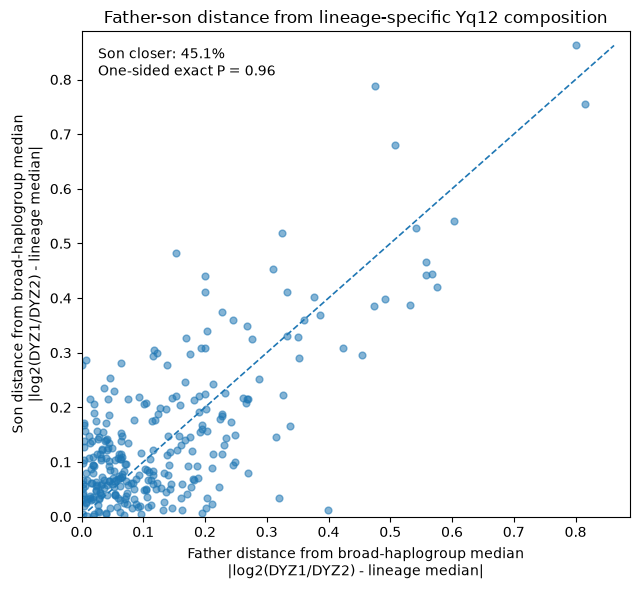

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 6.0))

x = broad_valid["YHaploBroad_Father_distance"].to_numpy(dtype=float)
y = broad_valid["YHaploBroad_Son_distance"].to_numpy(dtype=float)

ax.scatter(x, y, alpha=0.55, s=24)

limit = max(np.nanmax(x), np.nanmax(y))

ax.plot([0, limit], [0, limit], linestyle="--", linewidth=1.2)

ax.set_xlim(0, limit * 1.03)
ax.set_ylim(0, limit * 1.03)

ax.set_xlabel(
    "Father distance from broad-haplogroup median\n"
    "|log2(DYZ1/DYZ2) - lineage median|"
)
ax.set_ylabel(
    "Son distance from broad-haplogroup median\n"
    "|log2(DYZ1/DYZ2) - lineage median|"
)
ax.set_title(
    "Father-son distance from lineage-specific Yq12 composition"
)

ax.text(
    0.03,
    0.97,
    f"Son closer: {broad_lineage_summary['Son_closer_percent']:.1f}%\n"
    f"One-sided exact P = "
    f"{broad_lineage_summary['Exact_binomial_one_sided_P']:.3g}",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "father_son_broad_lineage_center_scatter.pdf",
    bbox_inches="tight",
)
plt.show()

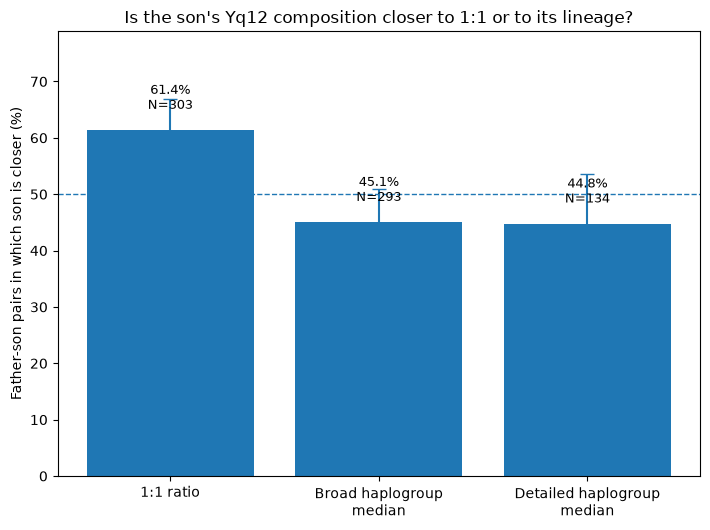

,Analysis,N_total,N_informative,Son_closer_N,Father_closer_N,Ties_N,Son_closer_percent,Exact_binomial_one_sided_P,Two_sided_95pct_Clopper_Pearson_CI_low,Two_sided_95pct_Clopper_Pearson_CI_high
0,Closer to universal 1:1 ratio,303,303,186,117,0,61.386139,0.000044,0.556495,0.668978
1,Closer to leave-pair-out broad-haplogroup median,293,293,132,161,0,45.051195,0.960255,0.392591,0.509444
2,Closer to leave-pair-out detailed-haplogroup m...,134,134,60,74,0,44.776119,0.902572,0.361847,0.536035


In [21]:
comparison = pd.DataFrame([
    one_to_one_summary,
    broad_lineage_summary,
    detailed_lineage_summary,
])

labels = [
    "1:1 ratio",
    "Broad haplogroup\nmedian",
    "Detailed haplogroup\nmedian",
]

p = comparison["Son_closer_proportion"].to_numpy(dtype=float)
ci_low = comparison["Two_sided_95pct_Clopper_Pearson_CI_low"].to_numpy(dtype=float)
ci_high = comparison["Two_sided_95pct_Clopper_Pearson_CI_high"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 5.4))

positions = np.arange(len(labels))

ax.bar(positions, p * 100)

ax.errorbar(
    positions,
    p * 100,
    yerr=np.vstack([
        (p - ci_low) * 100,
        (ci_high - p) * 100,
    ]),
    fmt="none",
    capsize=5,
)

ax.axhline(50, linestyle="--", linewidth=1)
ax.set_xticks(positions, labels)
ax.set_ylabel("Father-son pairs in which son is closer (%)")
ax.set_title(
    "Is the son's Yq12 composition closer to 1:1 or to its lineage?"
)

for pos, row in zip(positions, comparison.to_dict("records")):
    ax.text(
        pos,
        row["Son_closer_percent"] + 3,
        f"{row['Son_closer_percent']:.1f}%\n"
        f"N={row['N_informative']}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(
    0,
    min(100, max(75, float(np.max(ci_high * 100)) + 12)),
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "father_son_lineage_center_comparison.pdf",
    bbox_inches="tight",
)
plt.show()

display(
    comparison[
        [
            "Analysis",
            "N_total",
            "N_informative",
            "Son_closer_N",
            "Father_closer_N",
            "Ties_N",
            "Son_closer_percent",
            "Exact_binomial_one_sided_P",
            "Two_sided_95pct_Clopper_Pearson_CI_low",
            "Two_sided_95pct_Clopper_Pearson_CI_high",
        ]
    ]
)